# LMC coregionalization spatial BMCD — Spain + Portugal, every season

Fit and diagnostics of the **direct LMC** spatial BMCD (three latent fields $W^{(c)}, W^{(0)}, W^{(1)}$) on the ECAD rainfall-occurrence data of the Iberian (PT + ES) stations — 26 stations, 1980–2020, all four seasons.

- **model (4)** — shared mixing weight $\lambda$, $\theta=(\lambda,\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$ — *its fit and simulation are currently commented out*;
- **model (5)** — state-dependent weights $\lambda^{(0)}$ (dry) / $\lambda^{(1)}$ (wet), $\theta=(\lambda^{(0)},\lambda^{(1)},\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$ — the model used throughout.

Model: [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) §3. Estimation: pairwise composite likelihood, §3.2. Validation on simulated data: [tests_parameter_estimation.ipynb](tests_parameter_estimation.ipynb).

- **Part 1 — Fit.** Per season: observed per-year histories → pairwise MLE. $\hat\theta$ is cached in one CSV per model; already-fitted seasons are skipped on re-run.
- **Part 2 — Diagnostics.** Simulations at $\hat\theta_s$ compared with the observations over the same 1980–2020 period.

> Reasoning, construction details, caveats, **known issues and TODOs**: [NOTES_spatial_diagnostics.md](NOTES_spatial_diagnostics.md). Read it before changing anything here.


## Setup

Imports; single-site outputs of the data-preparation notebook (spell data, station metadata, fitted dry/wet parameters); per-season PT/ES station subsets with their exit-probability closures $q^{(0)}, q^{(1)}$; raw daily rainfall. The station set is settled in two passes — [NOTES](NOTES_spatial_diagnostics.md) §1.


In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    load_all_station_rr,
    filter_stations_by_nan_fraction,
    build_joint_df_occurrence_from_raw_data,
    history_from_Rbin_drop_ambiguous_spell_after_nan,
    split_history_by_year,
    mle_theta_pairwise_histories,
    simulate_cholesky_seasonal,
    THETA_BOUNDS_STATE_DEP,
    THETA_X0_STATE_DEP,
)
from spatial_bmcd.spatial_diagnostics import (
    spatial_station_order,
    plot_station_order_map,
    history_to_Rbin,
    plot_occurrence_raster_time_rows_pair,
)

# Single-site outputs of the data-preparation notebook.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)
stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

# Per-season PT/ES station subsets and exit-probability closures q0/q1.
COUNTRIES = ["PT", "ES"]
SEASONS = list(config.SEASONS)          # spring, summer, autumn, winter
YEAR_MIN, YEAR_MAX = 1980, 2020

def build_params_by_season(stations_used):
    """Per-season {city: model parameters} of the PT/ES subset of `stations_used`."""
    out = {}
    for season in SEASONS:
        df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
            df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=season,
        )
        out[season] = build_dict_model_params(
            df_fit_dry_sub, df_fit_wet_sub, spells, season=season, show_progress=False,
        )
    return out

# Station set, settled in two passes (NOTES_spatial_diagnostics.md, section 1).
per_season_params = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
# Raw daily RR, loaded once for the union of stations across seasons.
dfs_by_city = load_all_station_rr(config.ECAD_RAW_DIR, stations_to_get=stations_union, verbose=False)

stations_used = filter_stations_by_nan_fraction(stations_used, dfs_by_city)
per_season_params = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
dfs_by_city = {c: df for c, df in dfs_by_city.items() if c in stations_union}

print(f"{len(spells)} stations in spells JSON; PT/ES stations per season: "
      + ", ".join(f"{s}={len(per_season_params[s])}" for s in SEASONS)
      + f"; raw RR loaded for {len(dfs_by_city)}/{len(stations_union)} stations")

NaN filter (1980-2020, max 50% missing): 26/35 assessed stations kept
  dropped: BEARIZ (52%), FISTERRA (53%), ALMEIDINHA (54%), CAMPI (59%), TAVIRA (63%), GUARDA (66%), ENCISO (81%), HUELVA (90%), LLEIDA-AJUNTAMENT (100%)
209 stations in spells JSON; PT/ES stations per season: spring=26, summer=26, autumn=26, winter=26; raw RR loaded for 26/26 stations


## Fit $\theta$ per season — model (4), shared $\lambda$

$$
Z^{(r)}_n(\mathbf{s})=(-1)^{r}\sqrt{\lambda}\,W^{(c)}_n(\mathbf{s})+\sqrt{1-\lambda}\,W^{(r)}_n(\mathbf{s}),
\qquad r\in\{0,1\},\quad \lambda\in[0,1].
\tag{4}
$$

The cell builds the observed per-year histories once (reused by the model-(5) fit) and prints the workload per season, then runs the 4-D pairwise MLE (~10 min/season). Each fitted season is appended to `experiment_outputs/theta_fit_spain_portugal_by_season.csv` and skipped on re-run; delete the CSV to force a re-fit.

> The MLE call itself is **commented out** — [NOTES](NOTES_spatial_diagnostics.md) §0, item 1.


In [2]:
# --- Observed per-year histories, built once and shared by both model fits (fast). ---
def count_valid_pairs(histories):
    """Exact number of pairwise-likelihood terms (and active steps) a fit will evaluate."""
    total_pairs = n_steps = 0
    for h in histories:
        R, D, S = (np.asarray(h[k], float) for k in ("R", "D", "S"))
        for n in range(S.shape[0]):
            m = int((np.isfinite(R[n]) & np.isfinite(D[n]) & np.isfinite(S[n])).sum())
            if m >= 2:
                total_pairs += m * (m - 1) // 2
                n_steps += 1
    return total_pairs, n_steps

histories_by_season, params_by_station_by_season, workload_by_season = {}, {}, {}
for season in SEASONS:
    params = per_season_params[season]
    stations = sorted(c for c in params if c in dfs_by_city)
    Rbin = build_joint_df_occurrence_from_raw_data(
        dfs_by_city, season=season, station_names=stations,
        wet_day_threshold=float(config.WET_DAY_THRESHOLD),
    )
    Rbin = Rbin.loc[(Rbin.index.year >= YEAR_MIN) & (Rbin.index.year <= YEAR_MAX)]
    history = history_from_Rbin_drop_ambiguous_spell_after_nan(Rbin)
    histories_by_season[season] = split_history_by_year(history)
    params_by_station_by_season[season] = {c: params[c] for c in history["station_names"]}
    n_pairs, n_active_steps = count_valid_pairs(histories_by_season[season])
    years = pd.DatetimeIndex(history["dates"]).year
    workload_by_season[season] = {
        "n_stations": len(history["station_names"]),
        "n_years": int(years.nunique()),
        "n_pairs": n_pairs,
    }
    print(f"[{season:>6}] {len(history['station_names'])} stations, "
          f"{years.nunique()} years ({years.min()}-{years.max()}), "
          f"{n_active_steps} active steps, {n_pairs:,} pairwise terms")

OUTPUT_DIR = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def fit_theta_by_season(csv_path, theta_keys, mle_kwargs):
    """Fit theta season by season, appending to `csv_path` and skipping what is already there."""
    done = pd.read_csv(csv_path, index_col="season") if csv_path.exists() else None
    for season in SEASONS:
        if done is not None and season in done.index:
            print(f"[{season:>6}] already in {csv_path.name} -- skipped")
            continue
        print(f"[{season:>6}] fitting ({len(theta_keys)}-D pairwise MLE)...", flush=True)
        res = mle_theta_pairwise_histories(
            histories_by_season[season], params_by_station_by_season[season],
            vectorized=True, **mle_kwargs,
        )
        th = res["theta_hat"]
        row = pd.DataFrame([{
            "season": season, **workload_by_season[season],
            **{k: th[k] for k in theta_keys}, "ll": res["ll_hat"],
        }]).set_index("season")
        row.to_csv(csv_path, mode="a", header=not csv_path.exists())
        done = row if done is None else pd.concat([done, row])
    return done.loc[[s for s in SEASONS if s in done.index]]

# RESULTS_PATH = OUTPUT_DIR / "theta_fit_spain_portugal_by_season.csv"
# df_theta = fit_theta_by_season(RESULTS_PATH, ["lam", "sigma_wc", "sigma_w0", "sigma_w1"], {})
# print("\n" + df_theta[["lam", "sigma_wc", "sigma_w0", "sigma_w1", "ll"]].round(4).to_string())

[spring] 26 stations, 41 years (1980-2020), 3668 active steps, 528,970 pairwise terms
[summer] 26 stations, 41 years (1980-2020), 3652 active steps, 448,309 pairwise terms
[autumn] 26 stations, 41 years (1980-2020), 3615 active steps, 514,619 pairwise terms
[winter] 26 stations, 41 years (1980-2020), 3558 active steps, 511,522 pairwise terms


## Fit $\theta$ per season — model (5), state-dependent $\lambda^{(r)}$

The mixing weight now depends on the state $r$, so the covariance blocks become

$$
C^{(r,r')}_n(\mathbf{s},\mathbf{s}')=
\begin{cases}
\lambda^{(r)}\,\rho_{w^{(c)}}(\mathbf{s},\mathbf{s}')+(1-\lambda^{(r)})\,\rho_{w^{(r)}}(\mathbf{s},\mathbf{s}'), & r=r',\\[4pt]
-\,\sqrt{\lambda^{(0)}\lambda^{(1)}}\,\rho_{w^{(c)}}(\mathbf{s},\mathbf{s}'), & r\neq r'.
\end{cases}
\tag{5}
$$

Same per-year histories as model (4), which is the nested case $\lambda^{(0)}=\lambda^{(1)}$ — so the 5-D fit must reach at least the shared-$\lambda$ log-likelihood ($\Delta\ell\ge 0$). Same skip-if-saved behaviour, own CSV, somewhat longer runtime.


In [3]:
RESULTS_PATH_SD = OUTPUT_DIR / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"
df_theta_sd = fit_theta_by_season(
    RESULTS_PATH_SD, ["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"],
    {"bounds": THETA_BOUNDS_STATE_DEP, "x0": THETA_X0_STATE_DEP},
)
print("\n" + df_theta_sd[["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1", "ll"]].round(4).to_string())


[spring] already in theta_fit_spain_portugal_by_season_state_dep_lambda.csv -- skipped
[summer] already in theta_fit_spain_portugal_by_season_state_dep_lambda.csv -- skipped
[autumn] already in theta_fit_spain_portugal_by_season_state_dep_lambda.csv -- skipped
[winter] already in theta_fit_spain_portugal_by_season_state_dep_lambda.csv -- skipped

          lam0    lam1  sigma_wc  sigma_w0  sigma_w1           ll
season                                                           
spring  0.2935  0.7102  579.4817  470.4856    3.3952 -533054.6409
summer  0.8639  0.2946  337.2205  318.5314  287.3257 -298405.8477
summer  0.8639  0.2946  337.2205  318.5314  287.3257 -298405.8477
autumn  0.3829  0.5691  689.0578  527.9703  122.1870 -513087.6563
winter  0.3499  0.6349  783.8115  530.0983   84.1087 -487591.7924


# Part 2 — Diagnostics of the fitted models

The fit is treated as done: $\hat\theta_s$ per season is loaded from the CSVs saved above, so only the Setup cell is needed and no MLE is re-run. Simulations at $\hat\theta_s$ are compared with the observations over the same 1980–2020 period.


In [4]:
# Fitted theta per season for both models, saved by the fit sections of Part 1.
OUTPUT_DIR = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs"

def load_theta_by_season(csv_path, theta_keys):
    if not csv_path.exists():
        raise FileNotFoundError(
            f"{csv_path} not found: run the corresponding 'Fit theta per season' section of Part 1 once."
        )
    df = pd.read_csv(csv_path, index_col="season")
    return df, {s: tuple(r[k] for k in theta_keys) for s, r in df.iterrows()}

# df_theta, theta_by_season = load_theta_by_season(
#     OUTPUT_DIR / "theta_fit_spain_portugal_by_season.csv",
#     ["lam", "sigma_wc", "sigma_w0", "sigma_w1"],
# )
df_theta_sd, theta_by_season_sd = load_theta_by_season(
    OUTPUT_DIR / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv",
    ["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"],
)
print("model (4), shared lambda:")
# print(df_theta[["lam", "sigma_wc", "sigma_w0", "sigma_w1"]].round(4).to_string())
print("\nmodel (5), state-dependent lambda:")
print(df_theta_sd[["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"]].round(4).to_string())

model (4), shared lambda:

model (5), state-dependent lambda:
          lam0    lam1  sigma_wc  sigma_w0  sigma_w1
season                                              
spring  0.2935  0.7102  579.4817  470.4856    3.3952
summer  0.8639  0.2946  337.2205  318.5314  287.3257
summer  0.8639  0.2946  337.2205  318.5314  287.3257
autumn  0.3829  0.5691  689.0578  527.9703  122.1870
winter  0.3499  0.6349  783.8115  530.0983   84.1087


## Simulation across successive seasons

One continuous trajectory per model on the observed daily calendar, by the Cholesky algorithm of main.tex §5 (`simulate_cholesky_seasonal` in [spatial_model.py](spatial_model.py)), with season-dependent parameters:

- **latent fields** switch to $\hat\theta_{s(n)}$ on the first day of each new season;
- **exit probabilities** keep the season the spell *started* in (a spring dry spell keeps the spring $q^{(0)}$ even after summer has begun);
- **burn-in**: 1000 days prepended along the real season sequence, then discarded.

Marginally each station behaves as the single-site BMCD of its spell's season; the latent fields carry the spatial dependence and nothing else. Details: [NOTES](NOTES_spatial_diagnostics.md) §2.


In [5]:
# Common station set and observed full-calendar occurrence matrix (0/1/NaN, all seasons).
stations = sorted(
    set(dfs_by_city).intersection(*(set(p) for p in per_season_params.values()))
)
Rbin_obs = build_joint_df_occurrence_from_raw_data(
    dfs_by_city, season="all", station_names=stations,
    wet_day_threshold=float(config.WET_DAY_THRESHOLD),
)
Rbin_obs = Rbin_obs.loc[(Rbin_obs.index.year >= YEAR_MIN) & (Rbin_obs.index.year <= YEAR_MAX)]

# One simulated replicate per model, same calendar and same seed (a 5-tuple theta
# selects the state-dependent variant in simulate_cholesky_seasonal).
# Rbin_sim = history_to_Rbin(simulate_cholesky_seasonal(
#     Rbin_obs.index, theta_by_season, per_season_params,
#     station_names=stations, n_burn=1000, seed=0,
# ))
Rbin_sim_sd = history_to_Rbin(simulate_cholesky_seasonal(
    Rbin_obs.index, theta_by_season_sd, per_season_params,
    station_names=stations, n_burn=1000, seed=0,
))
print(f"observed {Rbin_obs.shape} (days x stations); "
    #   f"simulated: model (4) {Rbin_sim.shape}"
      f"model (5) {Rbin_sim_sd.shape}")

observed (14976, 26) (days x stations); model (5) (14976, 26)


### Spatial ordering of the stations

The plots below use the stations as an ordered axis: the 2-D station cloud is turned into a 1-D sequence in which list-neighbours are also map-neighbours (seriation of the inter-station distance matrix, by hierarchical clustering with optimal leaf ordering — appendix of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex)). The map shows where each column (left → right) sits geographically.


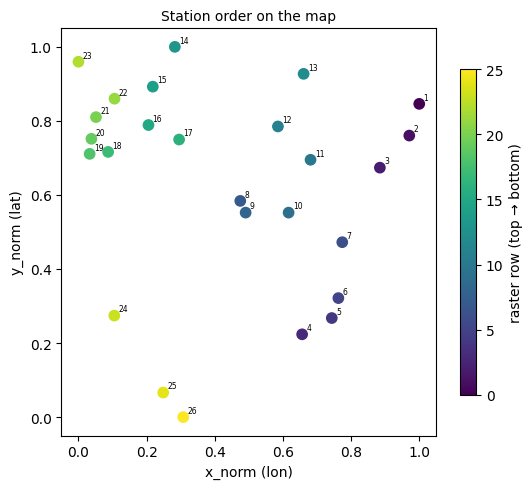

In [6]:
# Normalised coordinates are (near-)identical across seasons; use spring's.
params_xy = {c: per_season_params["spring"][c] for c in stations}
order = spatial_station_order(params_xy, stations)
plot_station_order_map(params_xy, stations, order=order);

## 1.b Observed vs simulated occurrence — model (5), state-dependent $\lambda^{(r)}$

Occurrence raster, observed against one model-(5) replicate (seed 0), on the same calendar, station order and reading grid.


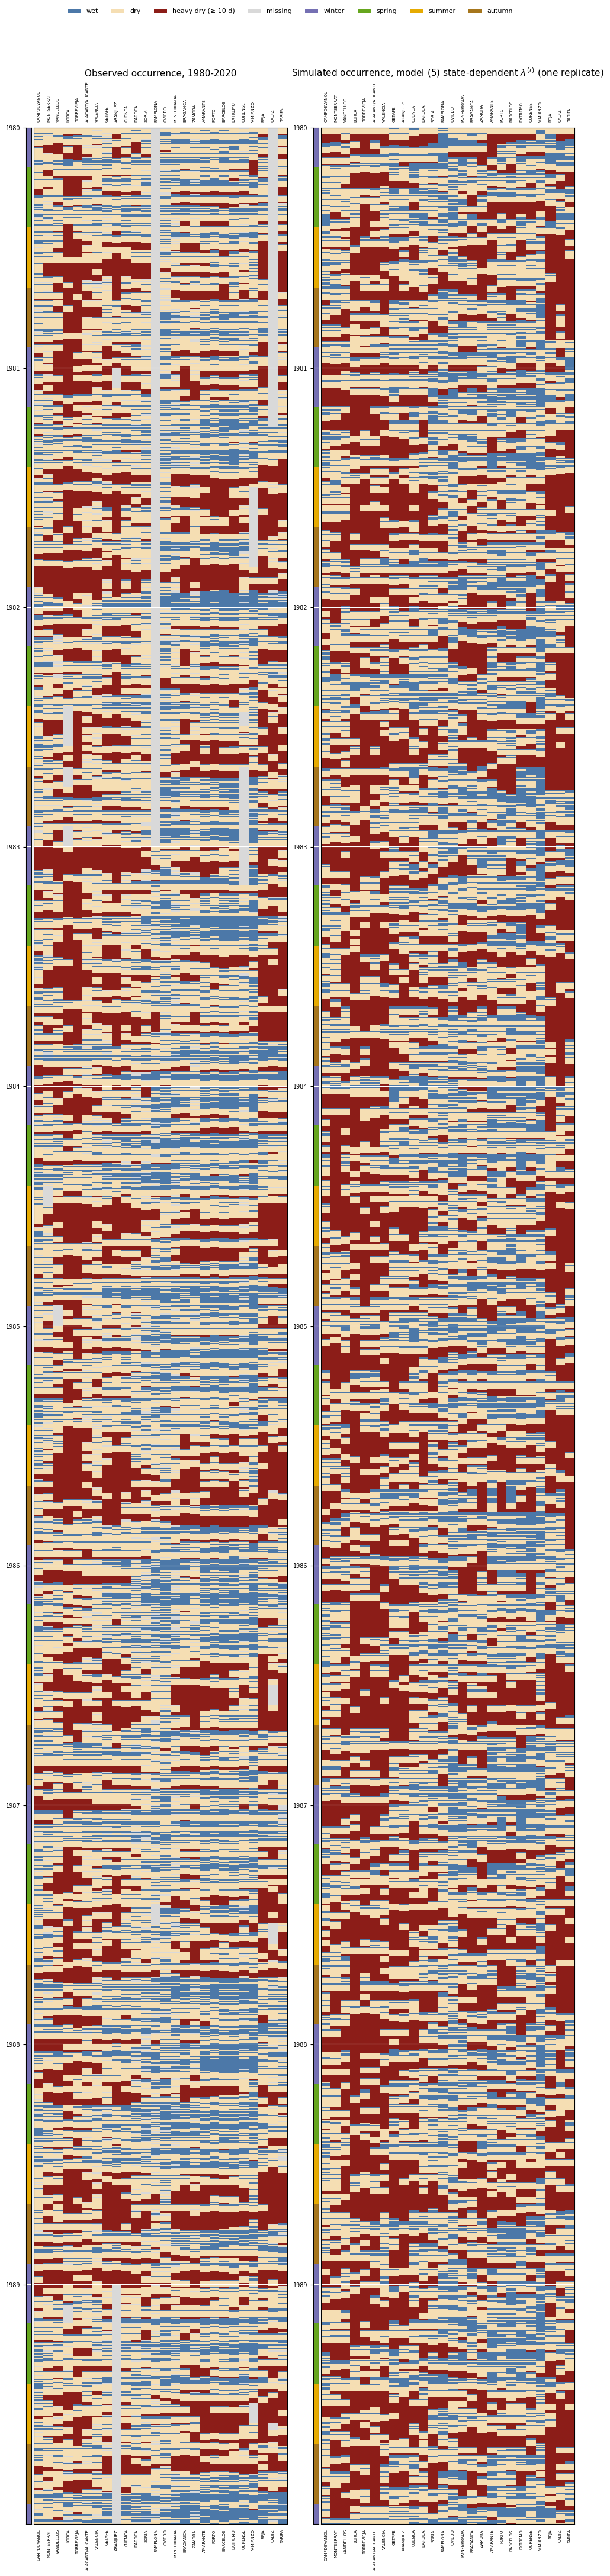

In [7]:
HEAVY_DRY_MIN_DAYS = 10


_ = plot_occurrence_raster_time_rows_pair(
    Rbin_obs, Rbin_sim_sd, params_xy, order=order,
    heavy_dry_min_days=HEAVY_DRY_MIN_DAYS,
    titles=("Observed occurrence, 1980-2020",
            "Simulated occurrence, model (5) state-dependent $\\lambda^{(r)}$ (one replicate)"),
    filename="diag_occurrence_obs_vs_sim_state_dep_lambda.pdf",
    station_width=0.15,
    time_window=("1980", "1989"),
    figsize=(24, 44),
)

## Replicate ensembles — model (5) and the no-spatial-structure null

A single trajectory cannot tell a genuine misfit from the wandering of one 41-year draw, which is exactly what matters in the tails the diagnostics below read. The cell builds **two** ensembles of `N_REPLICATES` seasonal Cholesky trajectories, on the observed calendar and masked with the observed NaN pattern:

- **`Rbin_sim_reps`** — model (5) at $\hat\theta_s$, seeds $0\dots N-1$ (replicate 0 is bit-for-bit the trajectory of 1.b);
- **`Rbin_indep_reps`** — the **independent-station null**: the same model with the three correlation ranges collapsed to $\sigma\to 0$, seeds $1000\dots$. Every correlation matrix becomes the identity, so each station runs its own single-site BMCD — with *exactly* the marginals of model (5), since $Z^{(r)}=\pm\sqrt{\lambda_r}W^{(c)}+\sqrt{1-\lambda_r}W^{(r)}$ is still $N(0,1)$ whatever $\lambda_r$ is. No refit is needed.

Sections 1.c–1.e draw both ensembles against the observations: median, plus the band between `BAND_QUANTILES` (5 %–95 %). A band is the model's sampling variability at $\hat\theta_s$ **fixed** — the estimation uncertainty on $\hat\theta_s$ is not propagated, so it is a *lower bound* on the total spread. Budget ≈ 2 × 7.5 min at 30 replicates, ≈ 50 MB per ensemble.

**Simulated once, then cached** ([simulation_cache.py](simulation_cache.py)). Each ensemble is stored in `experiment_outputs/sim_ensemble_cache/` under a fingerprint of everything it depends on: $\hat\theta_s$, the per-station parameters the simulator reads (`lat`/`lon` and the dry/wet tuples behind the $q$ closures), the station list, the calendar, the observed NaN mask, the seeds, `n_burn`, and the **source of the simulation call chain** (normalised through `ast`, so comments and reformatting do not count). Re-running the cell after a kernel restart, or while iterating on the plots below, reloads in a second; editing the model re-simulates on its own. `REFRESH_ENSEMBLES = True` forces a re-run, as does deleting the `.npz`; `list_cache()` shows what is stored.

> Why the null needs no refit, why the seed ranges are disjoint, what the *width* of a band means, and which diagnostic discriminates what: [NOTES_spatial_diagnostics.md](NOTES_spatial_diagnostics.md) §4–7.

In [8]:
from spatial_bmcd.spatial_model import station_distance_matrix
from spatial_bmcd.simulation_cache import CACHE_DIR, list_cache, simulate_ensemble_cached

# Number of independent trajectories behind every band of sections 1.c to 1.e,
# and the two quantiles the band is drawn between. Only the seed changes from
# one replicate to the next: same fitted theta, same calendar, same stations.
N_REPLICATES = 30
BAND_QUANTILES = (0.05, 0.95)
BAND_LABEL = f"{100 * (BAND_QUANTILES[1] - BAND_QUANTILES[0]):.0f}% band"

# Both ensembles are cached on disk under a fingerprint of everything they
# depend on -- theta, station parameters, calendar, mask, seeds, and the source
# of the simulation code path. A re-run with the same fingerprint reloads in a
# second; a changed model re-simulates on its own. Set to True to force a
# re-run (or delete the .npz in experiment_outputs/sim_ensemble_cache/).
REFRESH_ENSEMBLES = False

# Colour convention shared by every three-way figure below, and by the plotting
# helpers of spatial_diagnostics (which hard-code steelblue for the primary
# simulated ensemble and darkorange for the `*_alt` one they overlay).
COLOR_OBS, COLOR_SIM, COLOR_INDEP = "black", "steelblue", "darkorange"
LABEL_OBS = f"observed {YEAR_MIN}-{YEAR_MAX}"
LABEL_SIM = "model (5) $\\lambda^{(r)}$"
LABEL_INDEP = "independent stations"

# --- The no-spatial-structure null ---------------------------------------
# Ranges collapsed to ~0 => every correlation matrix is the identity, so each
# station runs its own single-site BMCD with exactly model (5)'s marginals.
# The lambdas are inert then and carried over unchanged; no refit is needed.
# Full argument in NOTES_spatial_diagnostics.md, section 4.
EPS_KM = 1e-6

theta_by_season_indep = {
    s: (th[0], th[1], EPS_KM, EPS_KM, EPS_KM)  # (lam0, lam1, sigma_wc, sigma_w0, sigma_w1)
    for s, th in theta_by_season_sd.items()
}

# exp(-h / EPS_KM) underflows to exactly 0 for any h > 0, but co-located
# stations would stay perfectly correlated whatever the range.
_D_km = station_distance_matrix(per_season_params["spring"], stations)
_d_min = _D_km[~np.eye(len(stations), dtype=bool)].min()
if _d_min <= 0:
    raise ValueError(
        "two stations share the same coordinates: the sigma -> 0 null keeps them "
        "perfectly correlated. Merge or drop one of them before using it."
    )
print(f"closest station pair: {_d_min:.1f} km -> exp(-h/{EPS_KM:g}) = "
      f"{np.exp(-_d_min / EPS_KM):g} off the diagonal (identity correlation)")


def simulate_ensemble(theta_by_season, seed0, label):
    """`N_REPLICATES` replicates on the observed calendar and NaN pattern, cached."""
    return simulate_ensemble_cached(
        dates=Rbin_obs.index,
        theta_by_season=theta_by_season,
        params_by_season=per_season_params,
        station_names=stations,
        seeds=range(seed0, seed0 + N_REPLICATES),
        mask=Rbin_obs,
        label=label,
        refresh=REFRESH_ENSEMBLES,
        n_burn=1000,
    )


def simulate_replicate(seed, theta_by_season=theta_by_season_sd):
    """One masked replicate on the observed calendar (model (5) by default).

    Same cache, so an ad-hoc single draw at a seed already in an ensemble still
    costs one simulation -- read the ensemble instead when the seed is in it.
    """
    return simulate_ensemble_cached(
        dates=Rbin_obs.index, theta_by_season=theta_by_season,
        params_by_season=per_season_params, station_names=stations,
        seeds=[seed], mask=Rbin_obs, label=f"single_seed{seed}",
        refresh=REFRESH_ENSEMBLES, verbose=False, n_burn=1000,
    )[0]


# Seed 0 first, so `Rbin_sim_reps[0]` is bit-for-bit the trajectory of 1.b.
# The null takes a disjoint seed range on purpose: the band-width claim of
# 1.c needs two independent ensembles (NOTES_spatial_diagnostics.md, section 5).
Rbin_sim_reps = simulate_ensemble(theta_by_season_sd, 0, "model5_state_dep")
Rbin_indep_reps = simulate_ensemble(theta_by_season_indep, 1000, "independent")

# The seed-0 model-(5) replicate under its single-run name, for any ad-hoc check.
Rbin_sim_masked = Rbin_sim_reps[0]

_cached = list_cache()
print(f"\n{CACHE_DIR.name}/: "
      + (f"\n{_cached.to_string(index=False)}" if len(_cached) else "empty"))

closest station pair: 29.8 km -> exp(-h/1e-06) = 0 off the diagonal (identity correlation)
[model5_state_dep] 1 replicate in 10.8 s -> ~5.4 min for 30
[model5_state_dep]   10/30 (102 s)
[model5_state_dep]   20/30 (220 s)
[model5_state_dep]   30/30 (361 s)
[model5_state_dep] 30 replicates of (14976, 26) (days x stations), 50 MB in RAM, 364 s -> cached as model5_state_dep_5bcd3aeae2e8bdf8.npz (2.9 MB)
[independent] 1 replicate in 14.3 s -> ~7.2 min for 30
[independent]   10/30 (143 s)
[independent]   20/30 (282 s)
[independent]   30/30 (418 s)
[independent] 30 replicates of (14976, 26) (days x stations), 50 MB in RAM, 422 s -> cached as independent_aedb79b09b40c2f2.npz (3.1 MB)

sim_ensemble_cache/: 
           label              key  n_replicates     seeds  n_stations               calendar             code  MB            modified
     independent aedb79b09b40c2f2            30 1000-1029          26 1980-01-01..2020-12-31 cfc6542c7936503e 3.1 2026-08-07 11:27:54
model5_state_dep 5bcd3ae

## 1.c Time spent in long spells — observed vs model (5)

With $L_n(\mathbf{s})$ the length in days of the spell containing day $n$ at station $\mathbf{s}$, and $\mathcal{V}$ the station-days carried by an uncensored spell,

$$
F^{(r)}(d)\;=\;\frac{\#\bigl\{(n,\mathbf{s})\in\mathcal{V}\;:\;R_n(\mathbf{s})=r,\;\;L_n(\mathbf{s})>d\bigr\}}{\#\,\mathcal{V}}\,,
\qquad d=0,1,2,\dots
$$

the share of station-days spent inside spells of type $r$ longer than $d$ days ($F^{(1)}(0)$ is the wet-day frequency, $F^{(0)}(0)+F^{(1)}(0)=1$). Time-weighted, so the long spells dominate the right tail. Pooled over the 26 stations, one horizon per panel (`D_MAX_BY_KIND`), log $y$ axis.

**Reading.** The observed curve should stay inside the model-(5) band over both horizons; a systematic drift out of it in the right tail is the model missing the long spells.

**The independent-station null is off by default** (`compare_independent=True` puts it back). With it, the two **medians should coincide** — the null shares model (5)'s marginals, so this checks that the LMC coupling has not distorted the spell law — and the model-(5) **band should be much wider** than the null's, because pooling over spatially dependent stations costs effective sample size; the `width ratio` row of the table is that statement in numbers, and a value $\gg 1$ is the headline.

> Censoring rule, band-resolution warning and the full argument: [NOTES](NOTES_spatial_diagnostics.md) §6–7.


wet spells, fraction of station-days (30 replicates per ensemble); 'width' = (p95 - p05) / p50
                  d=0      d=5     d=10     d=30
         obs   0.2774   0.0620   0.0201   0.0012
     sim p05   0.2689   0.0610   0.0178   0.0003
     sim p50   0.2722   0.0650   0.0195   0.0006
     sim p95   0.2762   0.0684   0.0218   0.0012
   sim width   0.0267   0.1147   0.2078   1.3770

dry spells, fraction of station-days (30 replicates per ensemble); 'width' = (p95 - p05) / p50
                  d=0      d=5     d=10    d=150
         obs   0.7226   0.5489   0.4016   0.0000
     sim p05   0.7238   0.5730   0.4215   0.0003
     sim p50   0.7278   0.5788   0.4293   0.0024
     sim p95   0.7311   0.5857   0.4363   0.0064
   sim width   0.0100   0.0219   0.0345   2.5680



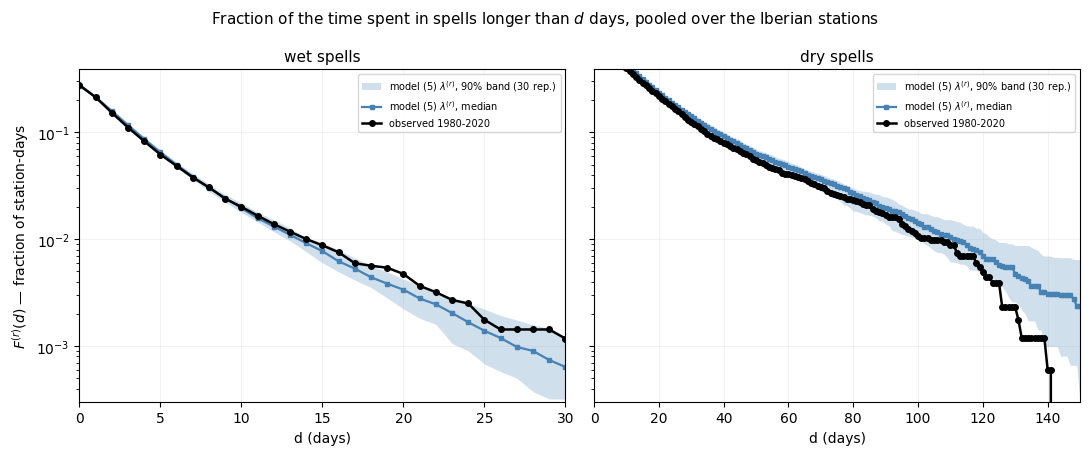

In [9]:
import matplotlib.pyplot as plt

# Same target as spatial_plotting.SPATIAL_FIGURES_DIR, without importing a
# private helper: `config` is already in scope from the Setup cell.
SPATIAL_FIGURES_DIR = config.ROOT / "figures" / "spatial"
SPATIAL_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Horizon of the d-axis, per spell type: wet spells are short, while dry
# spells in Iberia run much longer, so each panel gets its own range.
D_MAX_BY_KIND = {"wet": 30, "dry": 150}


def _complete_runs(col):
    """Run-length encode one station column -> (value, length, start) of the uncensored runs.

    Runs touching a NaN or a column edge are dropped -- the rule of
    `extract_complete_spells`, since their true length is cut short.
    """
    v = np.where(np.isfinite(col), col, -1.0)
    starts = np.concatenate(([0], np.flatnonzero(np.diff(v) != 0) + 1))
    lengths = np.diff(np.concatenate((starts, [v.size])))
    values = v[starts]
    keep = values >= 0
    keep[0] = keep[-1] = False
    keep[1:] &= values[:-1] >= 0
    keep[:-1] &= values[1:] >= 0
    return values[keep], lengths[keep], starts[keep]


def spell_time_fraction(Rbin, d_max=max(D_MAX_BY_KIND.values())):
    """F^(r)(d) = #{(n, s) in V : R_n(s) = r, L_n(s) > d} / #V, for d = 0..d_max.

    Share of station-days spent in spells of type r longer than d days, pooled
    over stations; V is the uncensored station-days, so F^(0)(0) + F^(1)(0) = 1.
    """
    runs = [_complete_runs(col) for col in np.asarray(Rbin, dtype=float).T]
    values = np.concatenate([v for v, _, _ in runs])
    lengths = np.concatenate([n for _, n, _ in runs]).astype(float)
    ds = np.arange(d_max + 1)
    return ds, {
        kind: np.array([lengths[(values == r) & (lengths > d)].sum() for d in ds])
        / lengths.sum()
        for kind, r in (("dry", 0.0), ("wet", 1.0))
    }


def frac_ensemble(reps):
    """(median, band) of F^(r)(d) over an ensemble, one entry per spell type.

    The d-grid is fixed, so the ensemble collapses column by column;
    `band[kind]` is the (2, d_max + 1) pair of `BAND_QUANTILES` rows.
    """
    per_rep = [spell_time_fraction(rep)[1] for rep in reps]
    stacked = {kind: np.vstack([f[kind] for f in per_rep]) for kind in ("wet", "dry")}
    return (
        {kind: np.median(a, axis=0) for kind, a in stacked.items()},
        {kind: np.quantile(a, BAND_QUANTILES, axis=0) for kind, a in stacked.items()},
    )


def _safe_div(num, den):
    """num / den elementwise, NaN wherever den <= 0 (the far tail, where both vanish)."""
    num, den = np.asarray(num, dtype=float), np.asarray(den, dtype=float)
    return np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)


def _relative_spread(med, band, kind):
    """(p95 - p05) / p50 of one ensemble: a scale-free band width per d."""
    return _safe_div(band[kind][1] - band[kind][0], med[kind])


def plot_spell_time_fraction(compare_independent=False):
    """F^(r)(d), observed against the model-(5) ensemble: one panel per spell type.

    With `compare_independent`, the sigma -> 0 null (`Rbin_indep_reps`) is drawn
    underneath and the table gains its band rows and the `width ratio` line --
    the spatial-dependence contrast of NOTES_spatial_diagnostics.md, sections
    6-7. Off by default: only the model-(5) band is drawn, and the figure keeps
    its own file name so the two versions do not overwrite each other.
    """
    ds, frac_obs = spell_time_fraction(Rbin_obs)
    frac_sim_med, frac_sim_band = frac_ensemble(Rbin_sim_reps)

    # Both ensembles are drawn the same way; the null comes first so that it
    # ends up underneath and the model-(5) band, the one under test, stays
    # readable where they overlap.
    ensembles = []
    if compare_independent:
        frac_indep_med, frac_indep_band = frac_ensemble(Rbin_indep_reps)
        ensembles.append((LABEL_INDEP, frac_indep_med, frac_indep_band, COLOR_INDEP))
    ensembles.append((LABEL_SIM, frac_sim_med, frac_sim_band, COLOR_SIM))

    # Shared y-axis -- all curves are shares of the same station-day total, so
    # the panels stay directly comparable -- but one d-range per panel.
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), sharey=True)
    for ax, kind in zip(axes, ("wet", "dry")):
        d_max = D_MAX_BY_KIND[kind]
        keep = ds <= d_max

        # Log axis: a zero lower edge maps to -inf and tears the polygon, so the
        # band is floored just below the smallest positive value drawn, and
        # dropped to NaN past the longest simulated spell.
        drawn = np.concatenate(
            [frac_obs[kind][keep]]
            + [med[kind][keep] for _, med, _, _ in ensembles]
            + [band[kind][1, keep] for _, _, band, _ in ensembles]
        )
        drawn = drawn[drawn > 0]
        floor = drawn.min() * 0.5 if drawn.size else 1e-6

        for label, med, band, color in ensembles:
            lo, hi = band[kind][:, keep]
            ax.fill_between(ds[keep],
                            np.where(hi > 0, np.maximum(lo, floor), np.nan),
                            np.where(hi > 0, hi, np.nan),
                            color=color, alpha=0.25, lw=0,
                            label=f"{label}, {BAND_LABEL} ({len(Rbin_sim_reps)} rep.)")
            ax.plot(ds[keep], med[kind][keep], color=color, lw=1.6, marker="s", ms=3.5,
                    label=f"{label}, median")
        ax.plot(ds[keep], frac_obs[kind][keep], color=COLOR_OBS, lw=1.8, marker="o", ms=4,
                label=LABEL_OBS)

        ax.set_yscale("log")
        ax.set_xlim(0, d_max)
        ax.set_ylim(bottom=floor)
        ax.set_xlabel("d (days)")
        ax.grid(alpha=0.25, lw=0.5)
        ax.set_title(f"{kind} spells", fontsize=11)
        ax.legend(fontsize=7)
    axes[0].set_ylabel("$F^{(r)}(d)$ — fraction of station-days")
    fig.suptitle("Fraction of the time spent in spells longer than $d$ days, "
                 "pooled over the Iberian stations", fontsize=11)
    fig.tight_layout()
    suffix = "_vs_independent" if compare_independent else ""
    fig.savefig(
        SPATIAL_FIGURES_DIR / f"diag_spell_time_fraction_state_dep_lambda{suffix}.pdf",
        bbox_inches="tight",
    )

    # Numeric counterpart of the bands. With the null, plus the ratio of their
    # relative widths -- how much of the model's own sampling spread is spatial
    # dependence. Meaningful here because F^(r)(d) pools the 26 stations, *not*
    # in 1.d (NOTES_spatial_diagnostics.md, sect. 7).
    for kind in ("wet", "dry"):
        ticks = [0, 5, 10, D_MAX_BY_KIND[kind]]
        p_lo, p_hi = (round(100 * q) for q in BAND_QUANTILES)
        spread_sim = _relative_spread(frac_sim_med, frac_sim_band, kind)
        rows = [
            ("obs", frac_obs[kind]),
            (f"sim p{p_lo:02d}", frac_sim_band[kind][0]),
            ("sim p50", frac_sim_med[kind]),
            (f"sim p{p_hi:02d}", frac_sim_band[kind][1]),
            ("sim width", spread_sim),
        ]
        if compare_independent:
            spread_ind = _relative_spread(frac_indep_med, frac_indep_band, kind)
            rows[4:4] = [
                (f"ind p{p_lo:02d}", frac_indep_band[kind][0]),
                ("ind p50", frac_indep_med[kind]),
                (f"ind p{p_hi:02d}", frac_indep_band[kind][1]),
            ]
            rows += [
                ("ind width", spread_ind),
                ("width ratio", _safe_div(spread_sim, spread_ind)),
            ]
        print(f"{kind} spells, fraction of station-days "
              f"({len(Rbin_sim_reps)} replicates per ensemble); "
              f"'width' = (p{p_hi:02d} - p{p_lo:02d}) / p50")
        print(" " * 12 + "".join(f"d={d}".rjust(9) for d in ticks))
        for label, curve in rows:
            print(f"{label:>12}" + "".join(f"{curve[d]:>9.4f}" for d in ticks))
        print()
    return fig


_ = plot_spell_time_fraction()

## 1.d Marginal law of the dry-spell duration — observed vs model (5) vs independent stations

The plain marginal distribution of the dry-spell duration $\tau^{(0)}$, season by season, with the same Q-Q reading as the single-site fit in [04_palermo_diagnostics.ipynb](../article_code/notebooks_article_pipeline/04_palermo_diagnostics.ipynb) — except that the simulated axis is read off the **spatial** trajectories rather than drawn i.i.d. from the fitted single-site law

$$
\tau^{(0)}\;\sim\;\hat f_1\,\delta_1+(1-\hat f_1)\,\bigl(2+\mathrm{extGPD}_1(\hat\xi,\hat\sigma,\hat\kappa)\bigr).
$$

So the question is whether the seasonal Cholesky simulation has left those marginals intact. One row per station (spread along the spatial ordering `order`), one column per season; spells filed under the season of their first day; plotting positions $p_i=(i-\tfrac12)/n$ fixed by the *observed* sample size, replicate pools thinned to $n$ (`QQ_MATCH_SAMPLE_SIZE`).

**Reading — and it differs from 1.c.** The pools here are *per station*, so the spatial dependence plays **no role**: the two bands should coincide in position *and* in width. The null is a **consistency check** here, not a contrast; a visible separation means the spatial layer has distorted the marginal, or the $\sigma\to0$ null is not independent. The genuine spatial contrast is 1.e.

> [NOTES](NOTES_spatial_diagnostics.md) §7 spells out which diagnostic discriminates what, and §0 item 5 the RNG caveat on the thinning.


dry-spell duration (days), per station (30 replicates per ensemble; 'sim' = model (5), 'ind' = independent stations)
                                n      mean       q50       q90       q99       max
CAMPDEVANOL spr     obs       369      3.37      2.00      8.00     17.32     23.00
CAMPDEVANOL spr sim p05       305      3.32      2.00      8.00     14.00     19.00
CAMPDEVANOL spr sim p50       326      3.79      2.00      9.00     17.00     23.50
CAMPDEVANOL spr sim p95       354      3.98      3.00      9.69     18.74     29.55
CAMPDEVANOL spr ind p05       305      3.38      2.00      8.00     14.00     18.00
CAMPDEVANOL spr ind p50       324      3.76      2.00      8.50     17.30     22.00
CAMPDEVANOL spr ind p95       355      4.01      3.00      9.11     19.95     32.55
CAMPDEVANOL sum     obs       396      3.53      3.00      8.00     14.05     22.00
CAMPDEVANOL sum sim p05       321      3.54      2.00      8.00     14.62     19.00
CAMPDEVANOL sum sim p50       348      3.87

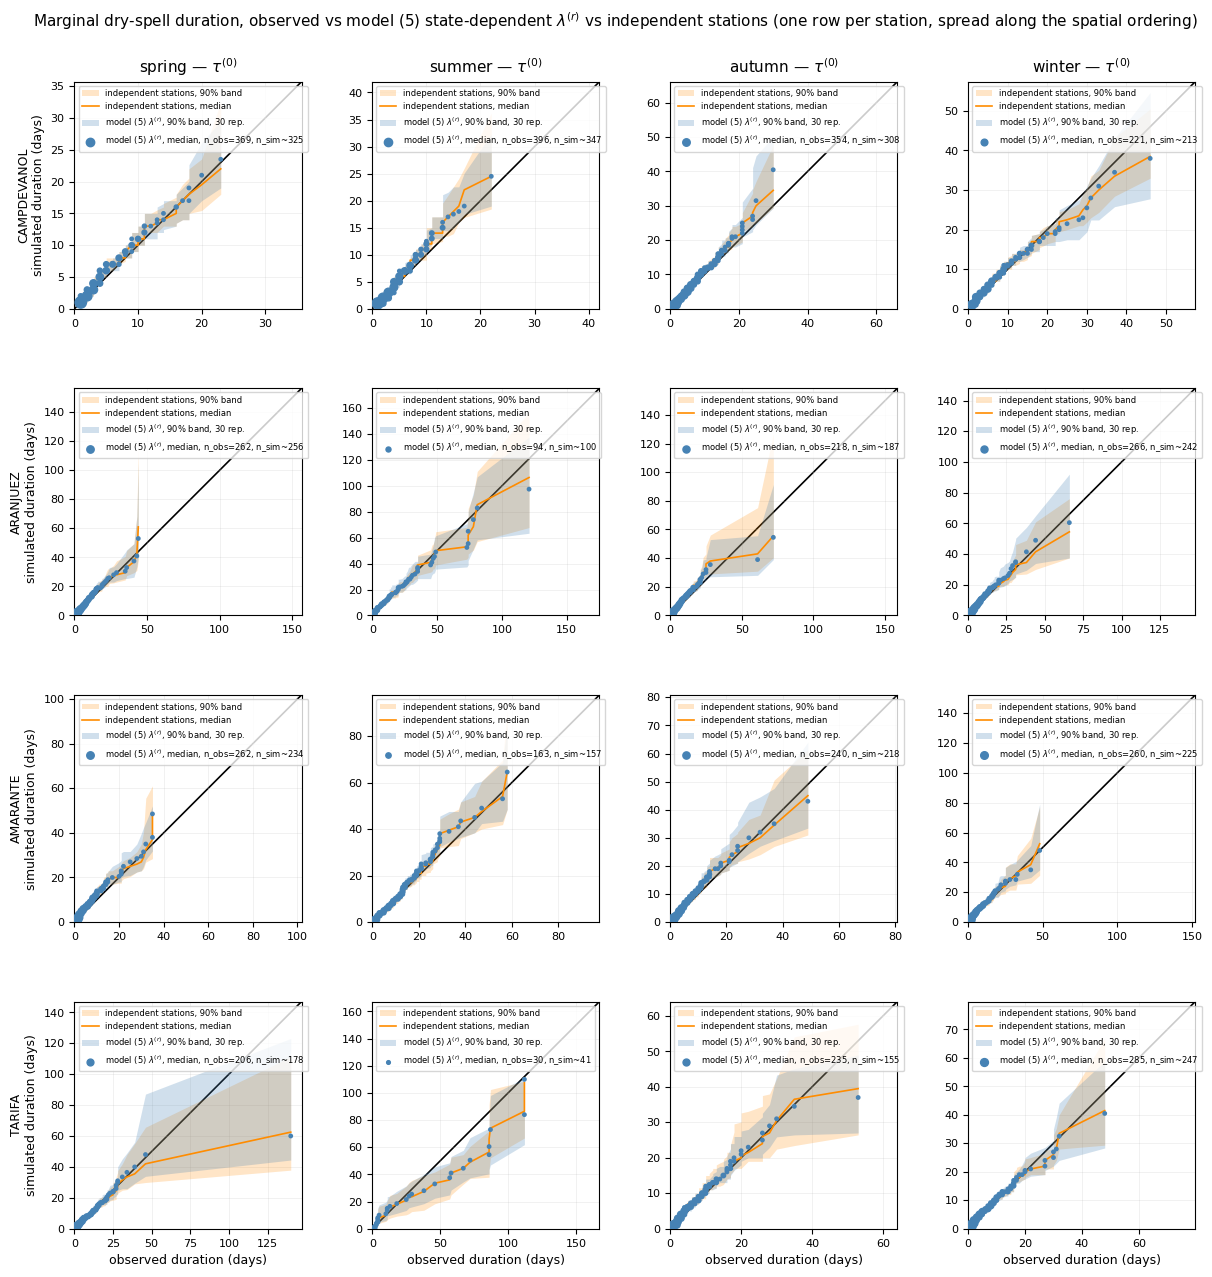

In [10]:
from spatial_bmcd.spatial_model import season_of_dates

# One row per station, the four seasons across the columns; stations picked
# evenly along the spatial ordering `order`, so the rows span the map.
N_QQ_STATIONS = 4

# Thin each replicate pool to the observed sample size before reading its
# quantiles, so a band is the spread of a record of the same length.
QQ_MATCH_SAMPLE_SIZE = True
QQ_SUBSAMPLE_SEED = 0


def qq_station_selection(n_stations, station_order=None):
    """`n_stations` stations spread evenly along the spatial ordering."""
    station_order = order if station_order is None else station_order
    idx = np.unique(np.linspace(0, len(station_order) - 1, n_stations).round().astype(int))
    return [station_order[i] for i in idx]


def dry_spells_by_station_season(Rbin, station_names):
    """{station: {season: durations}} of the uncensored dry-spell durations.

    A spell is filed under the season of its *first* day -- the stamping rule
    of `simulate_cholesky_seasonal`. Censoring is `_complete_runs`, as above.
    """
    dates = pd.DatetimeIndex(Rbin.index)
    pools = {}
    for name in station_names:
        values, lengths, starts = _complete_runs(np.asarray(Rbin[name], dtype=float))
        dry = values == 0.0
        labels = season_of_dates(dates[starts[dry]])
        pools[name] = {
            season: lengths[dry][labels == season].astype(float) for season in SEASONS
        }
    return pools


def _order_statistics(sample, p):
    """Inverted-CDF quantiles of `sample` at `p`, kept on the integer duration grid."""
    s = np.sort(np.asarray(sample, dtype=float))
    return s[np.clip(np.ceil(p * s.size).astype(int) - 1, 0, s.size - 1)]


def qq_dry_spell_band(obs, sim_pools, rng):
    """Q-Q of `obs` against each replicate at p = (i - 1/2)/n, n = observed sample size.

    Returns the observed order statistics and the (n_replicates, n) array of
    matching simulated quantiles; empty pools are dropped. Under
    `QQ_MATCH_SAMPLE_SIZE` a larger replicate pool is first thinned to n
    without replacement (NOTES_spatial_diagnostics.md, section 7).
    """
    obs_sorted = np.sort(np.asarray(obs, dtype=float))
    n = obs_sorted.size
    p = (np.arange(1, n + 1) - 0.5) / n
    curves = []
    for pool in sim_pools:
        pool = np.asarray(pool, dtype=float)
        if pool.size == 0:
            continue
        if QQ_MATCH_SAMPLE_SIZE and pool.size > n:
            pool = rng.choice(pool, size=n, replace=False)
        curves.append(_order_statistics(pool, p))
    return obs_sorted, (np.vstack(curves) if curves else np.empty((0, n)))


qq_stations = qq_station_selection(N_QQ_STATIONS)
obs_dry_by_station = dry_spells_by_station_season(Rbin_obs, qq_stations)
# Only the plotted stations are pooled, so each ensemble pass stays cheap.
sim_dry_by_station_reps = [
    dry_spells_by_station_season(rep, qq_stations) for rep in Rbin_sim_reps
]
indep_dry_by_station_reps = [
    dry_spells_by_station_season(rep, qq_stations) for rep in Rbin_indep_reps
]
qq_rng = np.random.default_rng(QQ_SUBSAMPLE_SEED)

# One row per station, one column per season: reading across a row compares the
# seasons of a single station, reading down a column compares the stations.
n_rows, n_cols = len(qq_stations), len(SEASONS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.1 * n_cols, 3.3 * n_rows),
                         squeeze=False)
for i, station in enumerate(qq_stations):
    for j, season in enumerate(SEASONS):
        ax = axes[i, j]
        obs_pool = obs_dry_by_station[station][season]
        sim_pools = [rep[station][season] for rep in sim_dry_by_station_reps]
        indep_pools = [rep[station][season] for rep in indep_dry_by_station_reps]
        if j == 0:
            ax.set_ylabel(f"{station}\nsimulated duration (days)", fontsize=9)
        if i == n_rows - 1:
            ax.set_xlabel("observed duration (days)", fontsize=9)
        if i == 0:
            ax.set_title(f"{season} — $\\tau^{{(0)}}$", fontsize=11)
        if obs_pool.size == 0 or all(pool.size == 0 for pool in sim_pools):
            ax.text(0.5, 0.5, "no complete dry spell", ha="center", va="center",
                    fontsize=8, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        obs_sorted, q_reps = qq_dry_spell_band(obs_pool, sim_pools, qq_rng)
        q_med = np.median(q_reps, axis=0)
        q_lo, q_hi = np.quantile(q_reps, BAND_QUANTILES, axis=0)
        _, q_ind = qq_dry_spell_band(obs_pool, indep_pools, qq_rng)

        hi_lim = max(obs_sorted[-1], q_hi[-1],
                     q_ind[:, -1].max() if q_ind.shape[0] else 0.0) * 1.05
        ax.plot([0, hi_lim], [0, hi_lim], color=COLOR_OBS, lw=1.2, zorder=1)

        # The null goes underneath. Its pools are *per station*, so it should
        # coincide with model (5) in position *and* in width -- a consistency
        # check, not a contrast (NOTES_spatial_diagnostics.md, section 7).
        if q_ind.shape[0]:
            ind_lo, ind_hi = np.quantile(q_ind, BAND_QUANTILES, axis=0)
            ax.fill_between(obs_sorted, ind_lo, ind_hi, color=COLOR_INDEP, alpha=0.22,
                            lw=0, zorder=2, label=f"{LABEL_INDEP}, {BAND_LABEL}")
            ax.plot(obs_sorted, np.median(q_ind, axis=0), color=COLOR_INDEP, lw=1.2,
                    zorder=4, label=f"{LABEL_INDEP}, median")
        ax.fill_between(obs_sorted, q_lo, q_hi, color=COLOR_SIM, alpha=0.25, lw=0,
                        zorder=3,
                        label=f"{LABEL_SIM}, {BAND_LABEL}, {q_reps.shape[0]} rep.")
        # Median curve: coincident pairs are merged into a single, larger marker.
        pairs, counts = np.unique(np.column_stack((obs_sorted, q_med)), axis=0,
                                  return_counts=True)
        n_sim_med = int(np.median([pool.size for pool in sim_pools]))
        ax.scatter(pairs[:, 0], pairs[:, 1],
                   s=np.minimum(6.0 * np.sqrt(counts), 400.0),
                   color=COLOR_SIM, zorder=5,
                   label=f"{LABEL_SIM}, median, n_obs={obs_sorted.size:,}, "
                         f"n_sim~{n_sim_med:,}")
        ax.set_xlim(0, hi_lim)
        ax.set_ylim(0, hi_lim)
        ax.set_aspect("equal")
        ax.grid(alpha=0.25, lw=0.5)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=6, loc="upper left")  # the emptiest corner of a Q-Q panel
fig.suptitle("Marginal dry-spell duration, observed vs model (5) state-dependent "
             "$\\lambda^{(r)}$ vs independent stations "
             "(one row per station, spread along the spatial ordering)", fontsize=11)
fig.tight_layout()
fig.savefig(SPATIAL_FIGURES_DIR / "diag_dry_spell_qq_state_dep_lambda.pdf",
            bbox_inches="tight")


def _pool_stats(pool):
    """(n, mean, q50, q90, q99, max) of one duration pool, or None if empty."""
    if pool.size == 0:
        return None
    return np.array([pool.size, pool.mean(),
                     *np.quantile(pool, [0.5, 0.9, 0.99]), pool.max()])


def _fmt_stats(stats):
    """One printed row: n as an integer, the five durations to two decimals."""
    return f"{stats[0]:>10.0f}" + "".join(f"{v:>10.2f}" for v in stats[1:])


# Every simulated statistic is quantiled across the replicates, so the p05/p50/p95
# rows are the numeric counterpart of the bands drawn above.
STAT_PROBS = (BAND_QUANTILES[0], 0.5, BAND_QUANTILES[1])

print(f"dry-spell duration (days), per station ({len(Rbin_sim_reps)} replicates "
      f"per ensemble; 'sim' = model (5), 'ind' = independent stations)")
print(f"{'':>23}" + "".join(f"{c:>10}" for c in
                            ("n", "mean", "q50", "q90", "q99", "max")))
for station in qq_stations:
    for season in SEASONS:
        head = f"{station[:11]:>11} {season[:3]} "
        obs_stats = _pool_stats(obs_dry_by_station[station][season])
        print(head + f"{'obs':>7}"
              + (_fmt_stats(obs_stats) if obs_stats is not None else f"{0:>10}"))
        for tag, reps in (("sim", sim_dry_by_station_reps),
                          ("ind", indep_dry_by_station_reps)):
            stats = [s for s in (_pool_stats(rep[station][season]) for rep in reps)
                     if s is not None]
            if not stats:
                print(head + f"{tag:>7}" + f"{0:>10}")
                continue
            for q, row in zip(STAT_PROBS,
                              np.quantile(np.vstack(stats), STAT_PROBS, axis=0)):
                print(head + f"{tag} p{round(100 * q):02d}".rjust(7) + _fmt_stats(row))